# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6**. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.

### Подготовка окружения и ноутбука

In [1]:
import os
from pathlib import Path

practice_dir_path = Path(os.getcwd()).absolute()
print(practice_dir_path)

os.chdir(practice_dir_path)

c:\Users\admin\Projects\labs\5\3\tsc\practice\06 Chains


In [2]:
%load_ext autoreload
%autoreload 2

Импорт библиотек и модулей

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

c:\Users\admin\Projects\labs\5\3\tsc\.venv\Lib\site-packages\stumpy\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


### **6.1.** Поиск цепочек временного ряда

Импорт библиотек и модулей

В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

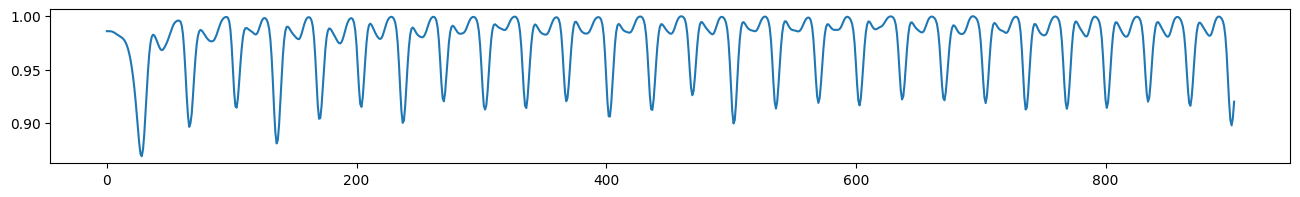

In [4]:
fig, ax = plt.subplots(figsize=(16, 2))
ts = np.loadtxt('datasets/Rotation Matrix.txt')
ax.plot(ts)

In [5]:
m = 50
mp = stumpy.stump(ts, m=m)
mp

array([[2.740822357842058, 109, -1, 109],
       [2.674516337770898, 110, -1, 110],
       [2.6397592653281485, 111, -1, 111],
       ...,
       [0.6954656428233177, 688, 688, -1],
       [0.8527226316079497, 689, 689, -1],
       [0.8139831346967186, 256, 256, -1]], shape=(855, 4), dtype=object)

In [ ]:
all_chain_set, chain = stumpy.allc(mp[:, 2], mp[:, 3])
chain

array([ 16,  55, 124, 490, 524, 591])

**Выводы:** Цепочка состоит из 6 звеньев

### **6.2.** Визуализация цепочек

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

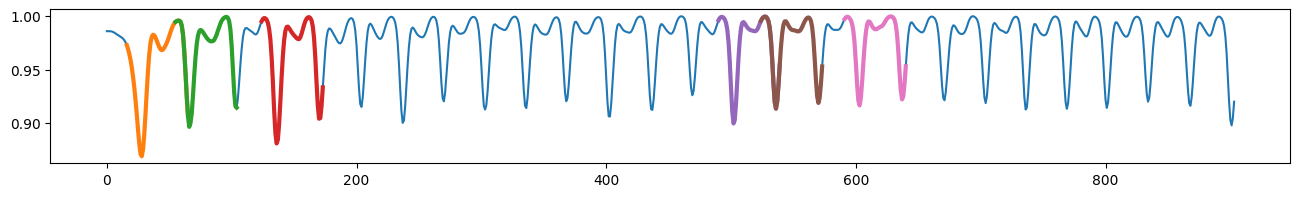

In [7]:
fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts)
for i in range(chain.shape[0]):
    y = ts[chain[i]:chain[i]+m]
    x = range(chain[i], chain[i]+m)
    plt.plot(x, y, linewidth=3)

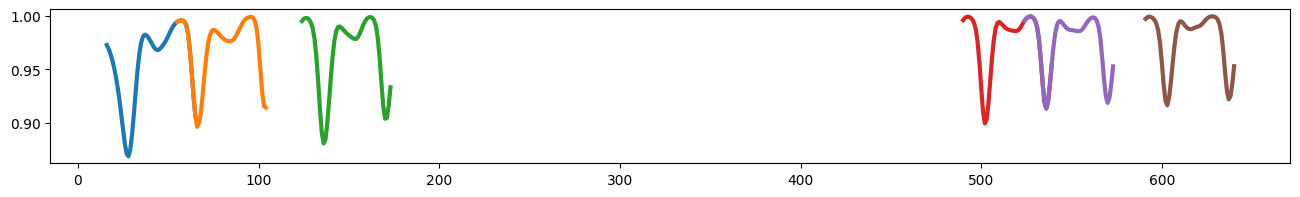

In [8]:
fig, ax = plt.subplots(figsize=(16, 2))
for i in range(chain.shape[0]):
    y = ts[chain[i]:chain[i]+m]
    x = range(chain[i], chain[i]+m)
    plt.plot(x, y, linewidth=3)    

**Выводы:** Звенья имеют схожу форму, но отличатся по размеру

### **6.3.** Предсказывание значений ряда на основе цепочек

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

In [9]:
i1, i2 = chain[-2:]
seg1 = ts[i1:i1+m]
seg2 = ts[i2:i2+m]

pred = seg2 + (seg2 - seg1)
real = ts[i2:i2+m]

accuracy = mean_squared_error(real, pred)
print(f"Точность предсказания (MSE): {accuracy*100:.4f}%")

Точность предсказания (MSE): 0.0009%


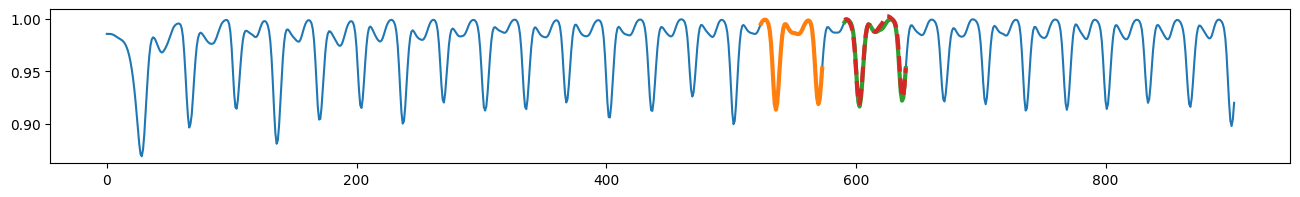

In [10]:
fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts)

for i in [-2, -1]:
    plt.plot(range(chain[i], chain[i] + m),
             ts[chain[i]:chain[i]+m], linewidth=3)

ax.plot(range(i2, i2 + m), pred, label="Predicted", linestyle='--', linewidth=3)

**Выводы:** Предсказанное значение практически совпало с реальным